Ashita Sharma 04101172025

Question 1. Load the Loan Prediction dataset and perform an initial analysis.
Tasks:
1. Display the first 10 records.
2. Identify all features and the target variable.
3. Determine the number of records and attributes.
4. Check for missing values.
5. Describe the statistical properties of numerical features.


In [15]:
import pandas as pd
#1.
data = pd.read_csv('loan_prediction.csv')
data.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [16]:
#2.
m_data = data.drop('Loan_ID', axis=1)
target_var = m_data['Loan_Status']
features = m_data.drop('Loan_Status', axis=1)
print(target_var)
print(features)

0      Y
1      N
2      Y
3      Y
4      Y
      ..
609    Y
610    Y
611    Y
612    Y
613    N
Name: Loan_Status, Length: 614, dtype: object
     Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0      Male      No          0      Graduate            No             5849   
1      Male     Yes          1      Graduate            No             4583   
2      Male     Yes          0      Graduate           Yes             3000   
3      Male     Yes          0  Not Graduate            No             2583   
4      Male      No          0      Graduate            No             6000   
..      ...     ...        ...           ...           ...              ...   
609  Female      No          0      Graduate            No             2900   
610    Male     Yes         3+      Graduate            No             4106   
611    Male     Yes          1      Graduate            No             8072   
612    Male     Yes          2      Graduate            No       

In [8]:
#3.
data.shape

(614, 12)

In [17]:
#4.
m_data.isna().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [18]:
#5.
m_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


Question 2. Perform data preprocessing.
Tasks:
1. Handle missing values using appropriate techniques.
2. Convert categorical variables into numerical format.
3. Normalize or standardize numerical features (if required).
4. Create the final feature matrix and target variable.


In [21]:
#1.
data_cleaned = m_data.dropna()
data_cleaned.shape

(480, 12)

In [48]:
#2.
x = data_cleaned.drop('Loan_Status', axis=1)
y = data_cleaned['Loan_Status']
x_encoded = pd.get_dummies(
    x,
    columns=['Gender', 'Married', 'Education', 'Self_Employed'],
    dtype=int
)
y_encoded = y.map({'N': 0, 'Y': 1})
area_map = {'Rural': 1, 'Semiurban': 2, 'Urban': 3}
x_encoded['Property_Area'] = x_encoded['Property_Area'].map(area_map)
x_encoded['Dependents'] = x_encoded['Dependents'].replace('3+', 3)
x_encoded['Dependents'] = x_encoded['Dependents'].astype(int)
print(x_encoded.dtypes)

Dependents                  int64
ApplicantIncome             int64
CoapplicantIncome         float64
LoanAmount                float64
Loan_Amount_Term          float64
Credit_History            float64
Property_Area               int64
Gender_Female               int64
Gender_Male                 int64
Married_No                  int64
Married_Yes                 int64
Education_Graduate          int64
Education_Not Graduate      int64
Self_Employed_No            int64
Self_Employed_Yes           int64
dtype: object


In [49]:
#3.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_encoded)

In [52]:
#4.
print(x_encoded.head())

   Dependents  ApplicantIncome  CoapplicantIncome  LoanAmount  \
1           1             4583             1508.0       128.0   
2           0             3000                0.0        66.0   
3           0             2583             2358.0       120.0   
4           0             6000                0.0       141.0   
5           2             5417             4196.0       267.0   

   Loan_Amount_Term  Credit_History  Property_Area  Gender_Female  \
1             360.0             1.0              1              0   
2             360.0             1.0              3              0   
3             360.0             1.0              3              0   
4             360.0             1.0              3              0   
5             360.0             1.0              3              0   

   Gender_Male  Married_No  Married_Yes  Education_Graduate  \
1            1           0            1                   1   
2            1           0            1                   1   
3    

Question 3. Perform exploratory data analysis to understand factors affecting loan approval.
Create at least five visualizations, such as:
1. Loan approval distribution.
2. Applicant income vs loan approval.
3. Credit history vs loan approval.
4. Education level vs loan approval.
5. Property area vs loan approval.


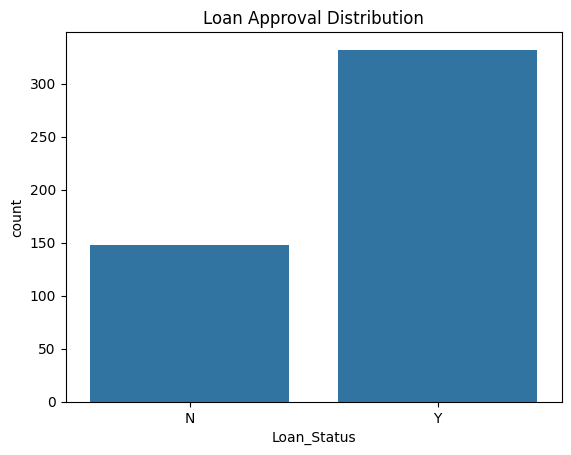

In [53]:
#1.
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Loan_Status', data=data_cleaned)
plt.title("Loan Approval Distribution")
plt.show()

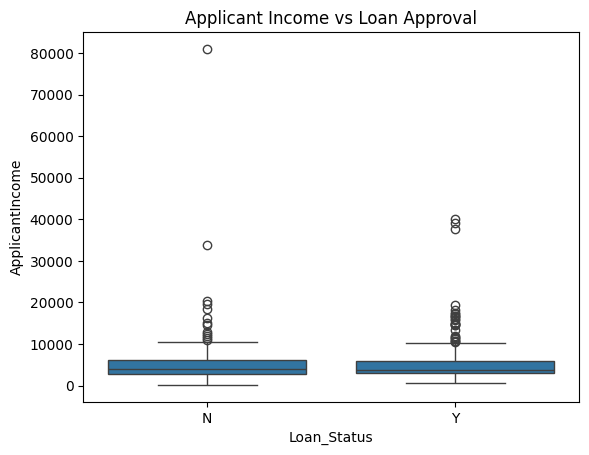

In [54]:
#2.
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=data_cleaned)
plt.title("Applicant Income vs Loan Approval")
plt.show()

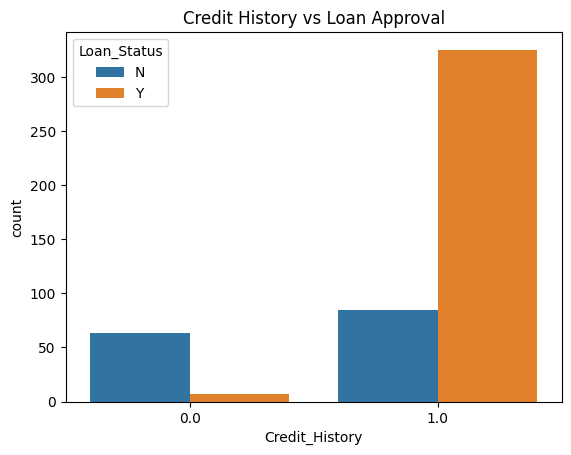

In [55]:
#3.
sns.countplot(x='Credit_History', hue='Loan_Status', data=data_cleaned)
plt.title("Credit History vs Loan Approval")
plt.show()

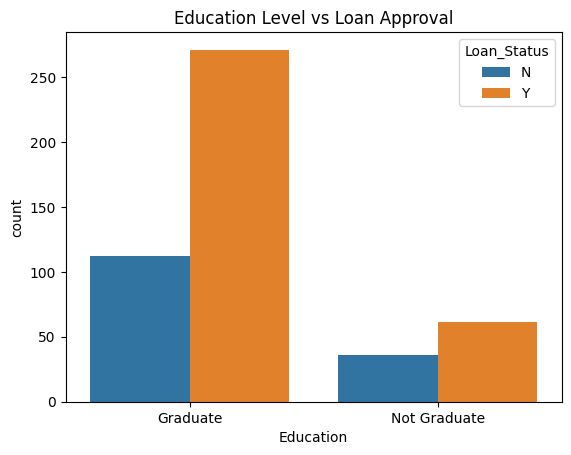

In [56]:
#4.
sns.countplot(x='Education', hue='Loan_Status', data=data_cleaned)
plt.title("Education Level vs Loan Approval")
plt.show()

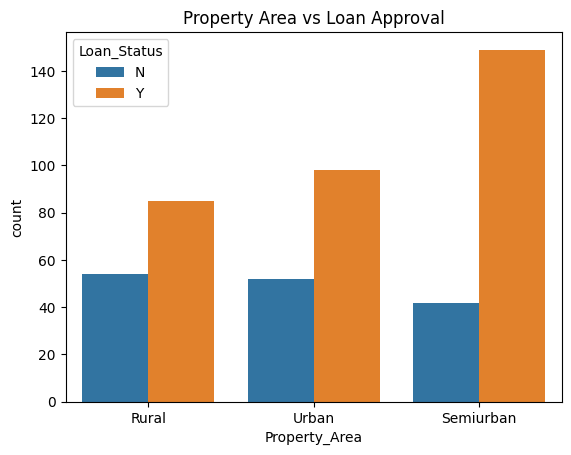

In [57]:
#5.
sns.countplot(x='Property_Area', hue='Loan_Status', data=data_cleaned)
plt.title("Property Area vs Loan Approval")
plt.show()

1. Which feature appears most influential in loan approval?
A: Credit history
2. What patterns can be observed from the visualizations?
Graduated, urban/semiurban applicants with a good credit history get loans approved quicker

Question 4. Split the dataset into training and testing sets (80:20).
Train the following models:
1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
For each model: Calculate Accuracy, Precision, Recall, F1 Score. Present the results in a comparison table.


In [58]:
import pandas as pd

X = pd.get_dummies(data_cleaned.drop('Loan_Status', axis=1), drop_first=True)
y = data_cleaned['Loan_Status'].map({'N': 0, 'Y': 1})

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Models
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)

# Train
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier(random_state=42)

In [60]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

In [61]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        evaluate_model(y_test, y_pred_lr)[0],
        evaluate_model(y_test, y_pred_dt)[0],
        evaluate_model(y_test, y_pred_rf)[0]
    ],
    "Precision": [
        evaluate_model(y_test, y_pred_lr)[1],
        evaluate_model(y_test, y_pred_dt)[1],
        evaluate_model(y_test, y_pred_rf)[1]
    ],
    "Recall": [
        evaluate_model(y_test, y_pred_lr)[2],
        evaluate_model(y_test, y_pred_dt)[2],
        evaluate_model(y_test, y_pred_rf)[2]
    ],
    "F1 Score": [
        evaluate_model(y_test, y_pred_lr)[3],
        evaluate_model(y_test, y_pred_dt)[3],
        evaluate_model(y_test, y_pred_rf)[3]
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.833333   0.828947  0.954545  0.887324
1        Decision Tree  0.718750   0.842105  0.727273  0.780488
2        Random Forest  0.791667   0.838235  0.863636  0.850746


Question 5. Based on the performance metrics:
1. Identify the best-performing model.
A: Logistic Regression
2. Justify your choice using evaluation metrics.
A: It has a high accuracy, recall and F1 score.
3. Discuss the strengths and limitations of each model.
A: Logistic regression is simple and fast to train but can easily struggle in non-linear patterns
Decision Tree is easy to understand and visualize but is very prone to overfitting and generally has a lower accuracy overall.
Random Forest is more accurate than a decision tree and is able to handle non-linear relations but is slower to train as well as computationally heavy.


Question 6. Apply Stratified 5-Fold Cross Validation to all three models.
Tasks:
1. Compute accuracy for each fold.
2. Calculate mean accuracy and standard deviation.
3. Compare cross-validation results with the train-test split results.


In [63]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr_scores = cross_val_score(lr, X, y, cv=skf, scoring='accuracy')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [64]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt_scores = cross_val_score(dt, X, y, cv=skf, scoring='accuracy')

In [65]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf_scores = cross_val_score(rf, X, y, cv=skf, scoring='accuracy')

In [66]:
print("Logistic Regression fold accuracies:", lr_scores)
print("Decision Tree fold accuracies:", dt_scores)
print("Random Forest fold accuracies:", rf_scores)

Logistic Regression fold accuracies: [0.75       0.85416667 0.78125    0.83333333 0.8125    ]
Decision Tree fold accuracies: [0.6875     0.6875     0.65625    0.75       0.77083333]
Random Forest fold accuracies: [0.75       0.84375    0.78125    0.83333333 0.76041667]


In [67]:
results_cv = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Mean Accuracy": [
        lr_scores.mean(),
        dt_scores.mean(),
        rf_scores.mean()
    ],
    "Std Deviation": [
        lr_scores.std(),
        dt_scores.std(),
        rf_scores.std()
    ]
})

print(results_cv)

                 Model  Mean Accuracy  Std Deviation
0  Logistic Regression       0.806250       0.037034
1        Decision Tree       0.710417       0.042898
2        Random Forest       0.793750       0.038074


1. Why is Stratified K-Fold preferred for this dataset?
A: Usually, loan datasets are imbalanced, e.g, some might have a lot of disapprovals but not a lot of approvals. Thus, the model can become unreliable due to biased training. Stratified k-fold prevents that.
2. Which model shows the most consistent performance?
The model with the most consistent performance is the model with a high accuracy as well as a low standard deviation. Here, the best performing model is the Logistic Regression.

Question 7. Perform hyperparameter tuning on the Random Forest Classifier using GridSearchCV. Tune the following parameters:
n_estimators = [50, 100, 200]
max_depth = [3, 5, 10]
min_samples_split = [2, 5, 10]
Tasks:
1. Identify the best parameter combination.
2. Report the best cross-validation score.
3. Evaluate the tuned model on the test set.
Compare:
Model performance before tuning
Model performance after tuning


In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

In [69]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.8020164046479836


In [70]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("Tuned Random Forest Accuracy:", tuned_accuracy)
print(classification_report(y_test, y_pred_tuned))

Tuned Random Forest Accuracy: 0.8125
              precision    recall  f1-score   support

           0       0.83      0.50      0.62        30
           1       0.81      0.95      0.88        66

    accuracy                           0.81        96
   macro avg       0.82      0.73      0.75        96
weighted avg       0.82      0.81      0.80        96



In [71]:
before_tuning = 0.7917  # replace with your actual value
after_tuning = tuned_accuracy

print("Before Tuning Accuracy:", before_tuning)
print("After Tuning Accuracy:", after_tuning)


Before Tuning Accuracy: 0.7917
After Tuning Accuracy: 0.8125


Tasks:
1. Identify the best parameter combination.

A: 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200

2. Report the best cross-validation score.
0.802
3. Evaluate the tuned model on the test set.
After tuning the accuracy increased by 2%.
Compare:
Model performance before tuning
Model performance after tuning

Before tuning, the accuracy was 79%, which is decent. However, after tuning, the accuracy was boosted to 81%.


Question 8. Train three Decision Tree models using:
max_depth = 2
max_depth = 5
max_depth = 15
For each model:
1. Compute training accuracy.
2. Compute testing accuracy.
3. Compare the results.
Answer:
1. Which model exhibits underfitting?
2. Which model exhibits overfitting?
3. Which model provides the best balance between bias and variance?
Present your findings in a table.


In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [73]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

models = {
    "Depth 2": DecisionTreeClassifier(max_depth=2, random_state=42),
    "Depth 5": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Depth 15": DecisionTreeClassifier(max_depth=15, random_state=42)
}

results = []

In [74]:
for name, model in models.items():
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append([name, train_acc, test_acc])

In [75]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model", "Training Accuracy", "Testing Accuracy"]
)

print(results_df)

      Model  Training Accuracy  Testing Accuracy
0   Depth 2           0.804688           0.81250
1   Depth 5           0.848958           0.81250
2  Depth 15           0.945312           0.71875


The underfitted data is depth 2, with a low training accuracy and a similar testing accuracy as the others. Depth 15 is overfitted as it performs great on training data but fails with testing data.